In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 解决中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)
n_samples=200
n_features = 10

true_coef = np.array([1.8,-2.2,0.9,0.6,0,0,0,0,0,0])

X = np.random.randn(n_samples,n_features)
y = np.dot(X,true_coef) + np.random.randn(n_samples)*0.8

print("="*50)
print("模拟数据集")
print("="*50)
print(f"样本数:{n_samples}")
print(f"特征数:{n_features}")
print(f"真实系数:{true_coef}")
print("说明:只有前4个特征（x1-x4）与房价相关，后6个是噪声特征")
from sklearn.linear_model import Lasso 
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr= LinearRegression()
lr.fit(X_train_scaled,y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)

lasso = Lasso(alpha=0.1,max_iter=10000)
lasso.fit(X_train_scaled,y_train)
print("\n"+"="*50)
print("三种模型性能对比")
print("="*50)
print(f"{'模型':<12}{'训练R²':<12}{'测试R²':<12}")
print("-"*40)
print(f"{'线性回归':<12}{lr.score(X_train_scaled,y_train):<12.4f}{lr.score(X_test_scaled,y_test):<12.4f}")
print(f"{'岭回归':<12}{ridge.score(X_train_scaled,y_train):<12.4f}{ridge.score(X_test_scaled,y_test):<12.4f}")
print(f"{'Lasso':<12}{lasso.score(X_train_scaled,y_train):<12.4f}{lasso.score(X_test_scaled,y_test):<12.4f}")

模拟数据集
样本数:200
特征数:10
真实系数:[ 1.8 -2.2  0.9  0.6  0.   0.   0.   0.   0.   0. ]
说明:只有前4个特征（x1-x4）与房价相关，后6个是噪声特征

三种模型性能对比
模型          训练R²        测试R²        
----------------------------------------
线性回归        0.9458      0.9524      
岭回归         0.9458      0.9521      
Lasso       0.9401      0.9458      


In [7]:
print("\n" + "="*60)
print("特征系数对比（Lasso的核心优势:让无用特征系数变0）")
print("="*60)
print(f"{'特征':<6}{'真实系数':<10}{'线性回归':<12}{'岭回归':12}{'Lasso':<12}{'说明'}")
print("-"*70)

for i in range(n_features):
    if true_coef[i] != 0:
        note = "<--有用特征"
    else:
        note = "<--噪声特征(Lasso会变0)"

    lasso_note = "成功变0" if (true_coef[i]==0 and abs(lasso.coef_[i])<0.01)else""

    print(f"x{i+1:<4}{true_coef[i]:<10.2f}{lr.coef_[i]:<12.4f}{ridge.coef_[i]:<12.4}{lasso.coef_[i]:<12.4f}{note}{lasso_note}")

nonzero_lr = np.sum(lr.coef_!=0)
nonzero_ridge = np.sum(ridge.coef_!=0)
nonzero_lasso= np.sum(np.abs(lasso.coef_)>=0.01)

print("\n"+"="*50)
print("特征保留统计")
print("="*50)
print(f"线性回归 保留的特征数:{nonzero_lr}(所有特征都有系数)")
print(f"岭回归   保留的特征数:{nonzero_ridge}(所有特征都有系数，但变小了)")
print(f"Lasso   保留的特征数：{nonzero_lasso}(只有重要的特征保留)")
print(f"\n真实有用的特征数:4")
print(f"Lasso正确识别并保留了{min(nonzero_lasso,4)}个有用的特征")
print(f"Lasso成功将{10 - nonzero_lasso}个噪声特征的系数变成了0！")


特征系数对比（Lasso的核心优势:让无用特征系数变0）
特征    真实系数      线性回归        岭回归         Lasso       说明
----------------------------------------------------------------------
x1   1.80      1.6996      1.689       1.5859      <--有用特征
x2   -2.20     -2.3377     -2.322      -2.2438     <--有用特征
x3   0.90      0.8295      0.8264      0.7681      <--有用特征
x4   0.60      0.6681      0.6631      0.5636      <--有用特征
x5   0.00      0.0142      0.01193     0.0000      <--噪声特征(Lasso会变0)成功变0
x6   0.00      -0.0689     -0.06736    -0.0000     <--噪声特征(Lasso会变0)成功变0
x7   0.00      -0.0778     -0.07643    -0.0000     <--噪声特征(Lasso会变0)成功变0
x8   0.00      -0.0513     -0.05139    -0.0000     <--噪声特征(Lasso会变0)成功变0
x9   0.00      0.0006      0.000449    -0.0000     <--噪声特征(Lasso会变0)成功变0
x10  0.00      0.1110      0.1104      0.0000      <--噪声特征(Lasso会变0)成功变0

特征保留统计
线性回归 保留的特征数:10(所有特征都有系数)
岭回归   保留的特征数:10(所有特征都有系数，但变小了)
Lasso   保留的特征数：4(只有重要的特征保留)

真实有用的特征数:4
Lasso正确识别并保留了4个有用的特征
Lasso成功将6个噪声特征的系数变成了0！


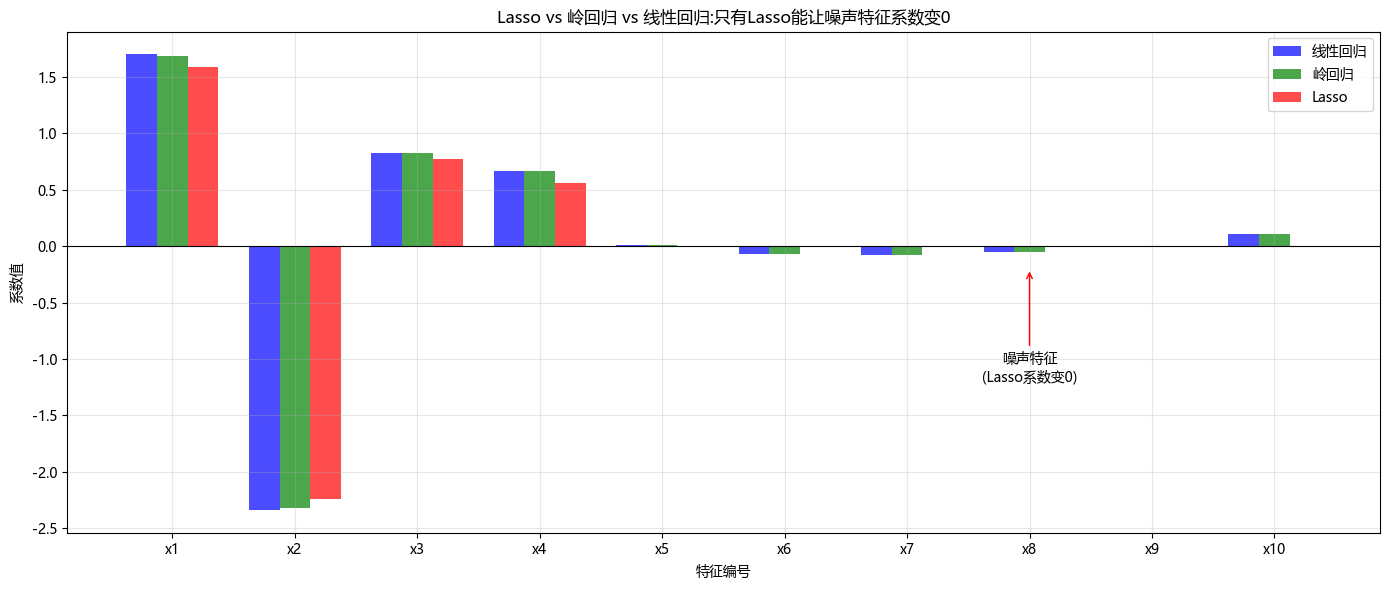

In [9]:
x_idx=np.arange(n_features)
width = 0.25

plt.figure(figsize=(14,6))
plt.bar(x_idx - width,lr.coef_,width,label='线性回归',color='blue',alpha=0.7)
plt.bar(x_idx,ridge.coef_,width,label='岭回归',color='green',alpha=0.7)
plt.bar(x_idx + width,lasso.coef_,width,label='Lasso',color='red',alpha=0.7)

plt.axhline(y=0,color='black',linestyle='-',linewidth=0.8)
plt.xlabel('特征编号')
plt.ylabel('系数值')
plt.title('Lasso vs 岭回归 vs 线性回归:只有Lasso能让噪声特征系数变0')
plt.legend()
plt.xticks(x_idx,[f'x{i+1}' for i in  range(n_features)])

plt.annotate('有用特征\n(系数非零)',xy=(1.5,2.0),xytext=(1.5,2.8),
             arrowprops=dict(arrowstyle='->',color='green'),fontsize=10,ha='center')
plt.annotate('噪声特征\n(Lasso系数变0)',xy=(7,-0.2),xytext=(7,-1.2),
             arrowprops=dict(arrowstyle='->',color='red'),fontsize=10,ha='center')

plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
alpha_values = [0.001,0.01,0.1,1,10]

print("\n"+"="*60)
print("不同alpha值的Lasso回归对比")
print("="*60)
print(f"{'alpha':<12}{'训练R²':<10}{'测试R²':<10}{'保留特征数':<12}{'说明'}")
print("-"*65)

for alpha in alpha_values:
    lasso_temp = Lasso(alpha=alpha,max_iter=10000)
    lasso_temp.fit(X_train_scaled,y_train)
    train_r2 = lasso_temp.score(X_test_scaled,y_test)
    test_r2 = lasso_temp.score(X_test_scaled,y_test)
    n_nonzero = np.sum(np.abs(lasso_temp.coef_)>=0.01)

    if alpha < 0.01:
        note = "接近线性回归"
    elif alpha > 1:
        note = "正则化太强，欠拟合"
    else:
        note = "适中"
    print(f"{alpha:<12}{train_r2:<10.4f}{test_r2:<10.4}{n_nonzero:<12}{note}")


不同alpha值的Lasso回归对比
alpha       训练R²      测试R²      保留特征数       说明
-----------------------------------------------------------------
0.001       0.9524    0.9524    9           接近线性回归
0.01        0.9523    0.9523    8           适中
0.1         0.9458    0.9458    4           适中
1           0.6374    0.6374    3           适中
10          -0.0141   -0.01407  0           正则化太强，欠拟合


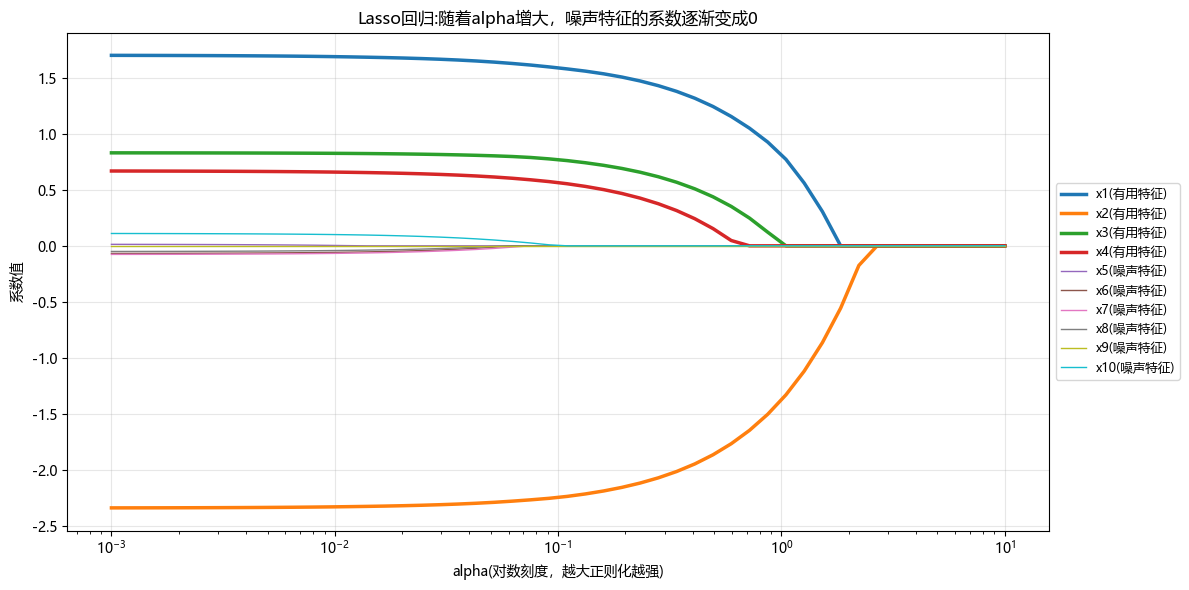


Lasso回归核心要点总结
1.Lasso使用L1正则化，能让不重要特征系数变成0
2.这相当于自动进行【特征选择】
3.alpha越小→接近线性回归，保留更多特征
4.alpha越大→正则化越强，更多特征变成0
5.需要用交叉验证选择最佳的alpha值


In [20]:
alpha_range = np.logspace(-3,1,50)
coef_trajectories = []

for alpha in alpha_range:
    lasso_temp = Lasso(alpha=alpha,max_iter=10000)
    lasso_temp.fit(X_train_scaled,y_train)
    coef_trajectories.append(lasso_temp.coef_)

coef_trajectories = np.array(coef_trajectories)

plt.figure(figsize=(12,6))
for i in range(n_features):
    if true_coef[i]!=0:
        linewidth = 2.5
        label = f'x{i+1}(有用特征)'
    else:
        linewidth=1.0
        label = f'x{i+1}(噪声特征)'
    plt.plot(alpha_range,coef_trajectories[:,i],linewidth=linewidth,label=label)

plt.xscale('log')
plt.xlabel('alpha(对数刻度，越大正则化越强)')
plt.ylabel('系数值')
plt.title('Lasso回归:随着alpha增大，噪声特征的系数逐渐变成0')
plt.legend(loc='center left',bbox_to_anchor=(1,0.5),fontsize=9)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

print("\n"+"="*50)
print("Lasso回归核心要点总结")
print("="*50)
print("1.Lasso使用L1正则化，能让不重要特征系数变成0")
print("2.这相当于自动进行【特征选择】")
print("3.alpha越小→接近线性回归，保留更多特征")
print("4.alpha越大→正则化越强，更多特征变成0")
print("5.需要用交叉验证选择最佳的alpha值")